# Timing Reliability Analysis

This notebook analyses timing reliability for a Go-based experimental package measured with a **Black Box Toolkit v3 (BBTKv3)** across four experimental conditions:

| Condition | Stimulus | BBTK sensor | Reference column |
|-----------|----------|-------------|------------------|
| `audio`  | 1000 Hz tone, 50 ms, 500 ms SOA  | Mic1   | `target_onset_ms`   |
| `av`     | Audio-visual, 1000 ms ITI         | Opto1+Mic1  | `t_visual_before_ms`|
| `flash`  | Flash, ~1028 ms ISI               | Opto1  | `t_before_ms`       |
| `frames` | 2 frames/phase, trigger on phase 1 | Opto1 | `t_before_ms` (triggered rows only) |

## 1. Setup

In [1]:
%matplotlib inline
from IPython.display import display

import glob
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# ── Plot defaults ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
COLORS = sns.color_palette("tab10", 5)   # one colour per condition

# ── Root directory ────────────────────────────────────────────────────────────
ROOT = Path(".")          # change to an absolute path if needed


## 2. Condition Metadata

Each condition has slightly different column names and filtering requirements.

In [2]:
# Per-condition configuration ---------------------------------------------------
#
# folder        : subdirectory under ROOT containing the data files
# ref_onset_col : column in the reference CSV holding the expected onset (ms)
# ref_filter    : optional (column, value) pair to pre-filter reference rows
# events_type   : if not None, filter bbtk events to this sensor type
# events_decimal: decimal character used in the events CSV ('.' or ',')
# label         : human-readable name used in plot titles and summaries

CONDITION_CFG = {
    "audio": {
        "folder":         "audio",
        "ref_onset_col":  "target_onset_ms",
        "ref_filter":     None,
        "events_type":    None,          # only Mic1 in this file
        "events_decimal": ",",           # European locale: 352,25 → 352.25
        "label":          "Audio",
    },
    "av_opto": {
        "folder":         "av",
        "ref_onset_col":  "t_visual_before_ms",
        "ref_filter":     None,
        "events_type":    "Opto1",       # visual channel only
        "events_decimal": ".",
        "label":          "AV — Visual (Opto1)",
    },
    "av_mic": {
        "folder":         "av",
        "ref_onset_col":  "t_audio_queued_ms",
        "ref_filter":     None,
        "events_type":    "Mic1",        # audio channel only
        "events_decimal": ".",
        "label":          "AV — Audio (Mic1)",
    },
    "flash": {
        "folder":         "flash",
        "ref_onset_col":  "t_before_ms",
        "ref_filter":     None,
        "events_type":    None,
        "events_decimal": ".",
        "label":          "Flash",
    },
    "frames": {
        "folder":         "frames",
        "ref_onset_col":  "t_before_ms",
        "ref_filter":     ("trigger", "true"),
        "events_type":    None,
        "events_decimal": ".",
        "label":          "Frames",
    },
}

CONDITIONS = list(CONDITION_CFG.keys())
print("Conditions:", CONDITIONS)


Conditions: ['audio', 'av_opto', 'av_mic', 'flash', 'frames']


## 3. Data Loading Functions

In [3]:
def _find_file(folder: Path, pattern: str) -> Path:
    """Return the first file matching *pattern* inside *folder*."""
    matches = sorted(folder.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No file matching '{pattern}' in {folder}")
    if len(matches) > 1:
        print(f"  [warn] Multiple files match '{pattern}' in {folder}; using {matches[0].name}")
    return matches[0]


def load_reference(condition: str) -> pd.Series:
    """
    Load the Timing-Tests reference file for *condition* and return the
    expected onset column as a float Series (ms, reset index).

    Handles:
    - Leading comment lines (starting with '#') are skipped
    - Trailing footer lines (also '#'-prefixed) are dropped by removing rows
      where the onset column is NaN
    - Row filtering (e.g. frames: keep trigger == true)
    """
    cfg = CONDITION_CFG[condition]
    folder = ROOT / cfg["folder"]
    path = _find_file(folder, "Timing-Tests_*.csv")

    # Count leading comment lines
    skip = 0
    with open(path) as fh:
        for line in fh:
            if line.startswith("#"):
                skip += 1
            else:
                break

    df = pd.read_csv(path, skiprows=skip)

    # Drop trailing footer rows (e.g. "# e end_time: ..." parsed as NaN)
    onset_col = cfg["ref_onset_col"]
    if onset_col in df.columns:
        df = df[df[onset_col].notna()]

    # Optional row filter — case-insensitive string comparison
    if cfg["ref_filter"] is not None:
        col, val = cfg["ref_filter"]
        df = df[df[col].astype(str).str.lower().str.strip() == val.lower()]

    if onset_col not in df.columns:
        raise KeyError(f"Column '{onset_col}' not found in {path.name}. "
                       f"Available: {list(df.columns)}")

    return (
        df[onset_col]
        .astype(str)
        .str.strip('"')
        .astype(float)
        .reset_index(drop=True)
    )


def load_events(condition: str) -> pd.Series:
    """
    Load the bbtk_*.events.csv file and return the Onset column as a
    float Series (ms, reset index).

    Handles:
    - European decimal separators (',')
    - Optional filtering by sensor type
    """
    cfg = CONDITION_CFG[condition]
    folder = ROOT / cfg["folder"]
    path = _find_file(folder, "bbtk_*.events.csv")

    df = pd.read_csv(path)

    # Filter by sensor type if required
    if cfg["events_type"] is not None:
        df = df[df["Type"] == cfg["events_type"]]

    onset_raw = df["Onset"].astype(str).str.strip('"')

    # Handle European decimal separator (audio condition uses ',' as decimal)
    if cfg["events_decimal"] == ",":
        onset_raw = onset_raw.str.replace(",", ".", regex=False)

    return onset_raw.astype(float).reset_index(drop=True)


## 4. Preprocessing Functions

In [4]:
def compute_intervals(onsets: pd.Series) -> pd.Series:
    """Return inter-event intervals (differences between consecutive onsets)."""
    return onsets.diff().dropna().reset_index(drop=True)


def align_intervals(expected: pd.Series, observed: pd.Series):
    """
    Align two interval series to the same length (shortest wins).
    Returns (exp_aligned, obs_aligned, n_discarded).
    """
    n = min(len(expected), len(observed))
    n_discarded = abs(len(expected) - len(observed))
    return expected.iloc[:n].reset_index(drop=True), \
           observed.iloc[:n].reset_index(drop=True), \
           n_discarded


def deviation_stats(expected: pd.Series, observed: pd.Series) -> pd.DataFrame:
    """Compute difference, absolute error and summary statistics."""
    diff = observed - expected
    abs_err = diff.abs()
    stats = pd.DataFrame({
        "metric": ["n", "mean_diff", "std_diff", "min_diff", "max_diff",
                   "mean_abs_err", "std_abs_err"],
        "value": [
            len(diff),
            diff.mean(), diff.std(), diff.min(), diff.max(),
            abs_err.mean(), abs_err.std(),
        ]
    }).set_index("metric")
    return stats

## 5. Outlier Detection Functions

In [5]:
def detect_outliers_iqr(series: pd.Series, k: float = 1.5):
    """
    IQR-based outlier detection.

    Returns
    -------
    mask       : boolean Series, True where value is an outlier
    lower, upper : fence values
    """
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    mask = (series < lower) | (series > upper)
    return mask, lower, upper


def describe_full(series: pd.Series, label: str = "") -> pd.DataFrame:
    """Extended descriptive statistics (min/max/mean/std/median/p5/p95)."""
    pcts = series.quantile([0.05, 0.25, 0.50, 0.75, 0.95])
    return pd.DataFrame({
        "n":      len(series),
        "mean":   series.mean(),
        "std":    series.std(),
        "min":    series.min(),
        "p5":     pcts[0.05],
        "p25":    pcts[0.25],
        "median": pcts[0.50],
        "p75":    pcts[0.75],
        "p95":    pcts[0.95],
        "max":    series.max(),
    }, index=[label])

## 6. Plotting Functions

In [6]:
def plot_boxplot_with_outliers(obs_intervals: pd.Series, mask: pd.Series,
                               lower: float, upper: float,
                               condition: str, ax: plt.Axes, color):
    """Boxplot of observed intervals with outlier fences annotated."""
    ax.boxplot(obs_intervals.dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5),
               medianprops=dict(color="black", linewidth=2),
               flierprops=dict(marker="o", markerfacecolor="red",
                               markersize=7, linestyle="none"))
    ax.axhline(lower, color="red", linestyle="--", linewidth=1,
               label=f"IQR fence ({lower:.1f} – {upper:.1f} ms)")
    ax.axhline(upper, color="red", linestyle="--", linewidth=1)
    n_out = mask.sum()
    ax.set_title(f"{condition}\n{n_out} outlier(s) out of {len(obs_intervals)}")
    ax.set_ylabel("Observed interval (ms)")
    ax.set_xticks([])
    ax.legend(fontsize=8)


def plot_histogram_comparison(exp_clean: pd.Series, obs_clean: pd.Series,
                               condition: str, ax: plt.Axes, color):
    """Overlaid histogram of expected vs observed intervals (after outlier removal)."""
    all_vals = pd.concat([exp_clean, obs_clean]).dropna()
    bins = np.linspace(all_vals.min() - 1, all_vals.max() + 1, 40)

    ax.hist(exp_clean, bins=bins, alpha=0.55, label="Expected",
            color="#888888", edgecolor="white")
    ax.hist(obs_clean, bins=bins, alpha=0.55, label="Observed",
            color=color, edgecolor="white")

    ax.axvline(exp_clean.mean(), color="#888888", linestyle="--",
               linewidth=1.5, label=f"E mean={exp_clean.mean():.1f}")
    ax.axvline(obs_clean.mean(), color=color, linestyle="--",
               linewidth=1.5, label=f"O mean={obs_clean.mean():.1f}")

    ax.set_title(condition)
    ax.set_xlabel("Interval (ms)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)


def plot_deviation_timeseries(diff: pd.Series, condition: str,
                               ax: plt.Axes, color):
    """Deviation (observed − expected) over event index."""
    ax.plot(diff.index, diff.values, marker="o", markersize=3,
            linewidth=1, color=color, alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
    ax.axhline(diff.mean(), color=color, linewidth=1.2, linestyle="--",
               label=f"mean={diff.mean():.2f} ms")
    ax.set_title(condition)
    ax.set_xlabel("Interval index")
    ax.set_ylabel("Deviation (ms)")
    ax.legend(fontsize=8)

## 7. Main Analysis Loop

Run the full pipeline for all four conditions and collect results.

In [7]:
results = {}  # condition → dict of processed data

for cond in CONDITIONS:
    cfg = CONDITION_CFG[cond]
    print(f"\n{'='*60}")
    print(f"  Condition: {cfg['label'].upper()}")
    print(f"{'='*60}")

    # --- 7.1 Load -------------------------------------------------------
    ref_onsets = load_reference(cond)
    obs_onsets = load_events(cond)
    print(f"  Reference events : {len(ref_onsets)}")
    print(f"  BBTK events      : {len(obs_onsets)}")

    # --- 7.2 Compute intervals ------------------------------------------
    exp_intervals = compute_intervals(ref_onsets)
    obs_intervals = compute_intervals(obs_onsets)

    exp_aln, obs_aln, n_disc = align_intervals(exp_intervals, obs_intervals)
    if n_disc > 0:
        print(f"  [!] Length mismatch: {len(exp_intervals)} expected vs "
              f"{len(obs_intervals)} observed. "
              f"Trimmed to {len(exp_aln)} pairs (discarded {n_disc}).")

    # --- 7.3 Deviation stats (before cleaning) --------------------------
    stats_raw = deviation_stats(exp_aln, obs_aln)
    print("\n  Deviation stats (raw, before outlier removal):")
    print(stats_raw.round(3).to_string())

    # --- 7.4 Outlier detection ------------------------------------------
    mask, lo, hi = detect_outliers_iqr(obs_aln)
    outlier_vals = obs_aln[mask]
    print(f"\n  IQR fences: [{lo:.3f}, {hi:.3f}] ms")
    print(f"  Outliers detected: {mask.sum()}")
    if mask.sum() > 0:
        print(f"  Outlier values (ms): {outlier_vals.values.tolist()}")

    # --- 7.5 Clean data -------------------------------------------------
    keep = ~mask
    exp_clean = exp_aln[keep].reset_index(drop=True)
    obs_clean = obs_aln[keep].reset_index(drop=True)
    stats_clean = deviation_stats(exp_clean, obs_clean)
    print("\n  Deviation stats (cleaned):")
    print(stats_clean.round(3).to_string())

    # --- 7.6 Descriptive stats -----------------------------------------
    desc = pd.concat([
        describe_full(exp_clean, "expected"),
        describe_full(obs_clean, "observed"),
    ])
    print("\n  Interval descriptive statistics (cleaned):")
    print(desc.round(3).to_string())

    # --- Store ---------------------------------------------------------
    results[cond] = {
        "label":         cfg["label"],
        "exp_intervals": exp_intervals,
        "obs_intervals": obs_intervals,
        "exp_aln":       exp_aln,
        "obs_aln":       obs_aln,
        "outlier_mask":  mask,
        "iqr_lo": lo, "iqr_hi": hi,
        "exp_clean":     exp_clean,
        "obs_clean":     obs_clean,
        "stats_raw":     stats_raw,
        "stats_clean":   stats_clean,
        "desc":          desc,
    }

print("\n✓ All conditions processed.")



  Condition: AUDIO
  Reference events : 30
  BBTK events      : 22
  [!] Length mismatch: 29 expected vs 21 observed. Trimmed to 21 pairs (discarded 8).

  Deviation stats (raw, before outlier removal):
               value
metric              
n             21.000
mean_diff     -0.167
std_diff       2.460
min_diff      -4.000
max_diff       1.500
mean_abs_err   2.095
std_abs_err    1.213

  IQR fences: [488.375, 509.375] ms
  Outliers detected: 0

  Deviation stats (cleaned):
               value
metric              
n             21.000
mean_diff     -0.167
std_diff       2.460
min_diff      -4.000
max_diff       1.500
mean_abs_err   2.095
std_abs_err    1.213

  Interval descriptive statistics (cleaned):
           n     mean   std    min     p5     p25  median    p75    p95    max
expected  21  500.000  0.00  500.0  500.0  500.00  500.00  500.0  500.0  500.0
observed  21  499.833  2.46  496.0  496.0  496.25  501.25  501.5  501.5  501.5

  Condition: AV — VISUAL (OPTO1)
  Reference

## 8. Outlier Detection — Boxplots

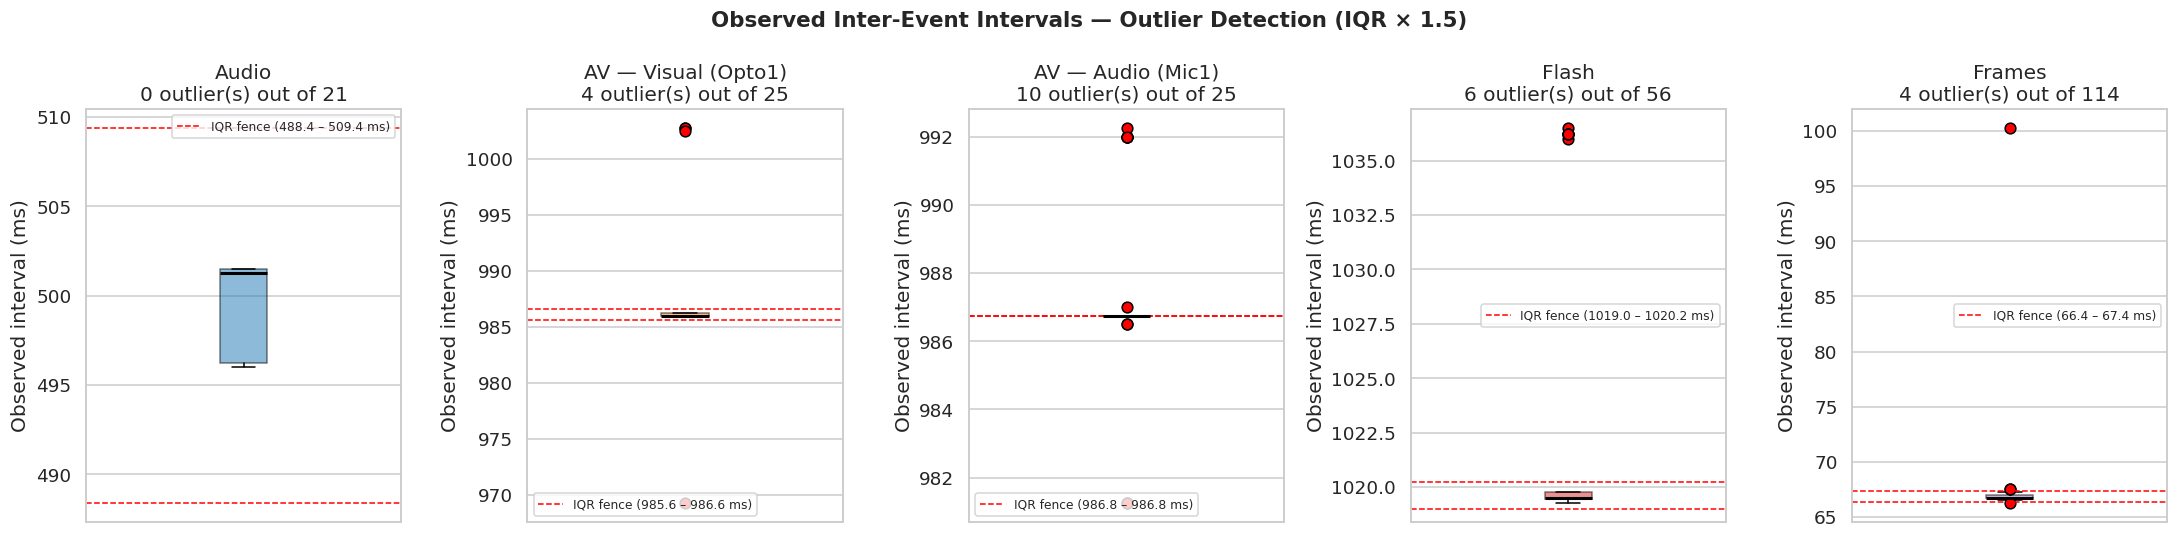

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Observed Inter-Event Intervals — Outlier Detection (IQR × 1.5)",
             fontsize=14, fontweight="bold")

for ax, cond, color in zip(axes, CONDITIONS, COLORS):
    r = results[cond]
    plot_boxplot_with_outliers(
        r["obs_aln"], r["outlier_mask"],
        r["iqr_lo"], r["iqr_hi"],
        r["label"], ax, color
    )

plt.tight_layout()
plt.savefig(ROOT / "boxplots_outlier_detection.png", bbox_inches="tight")
plt.show()


## 9. Distribution Analysis — Expected vs Observed (Cleaned)

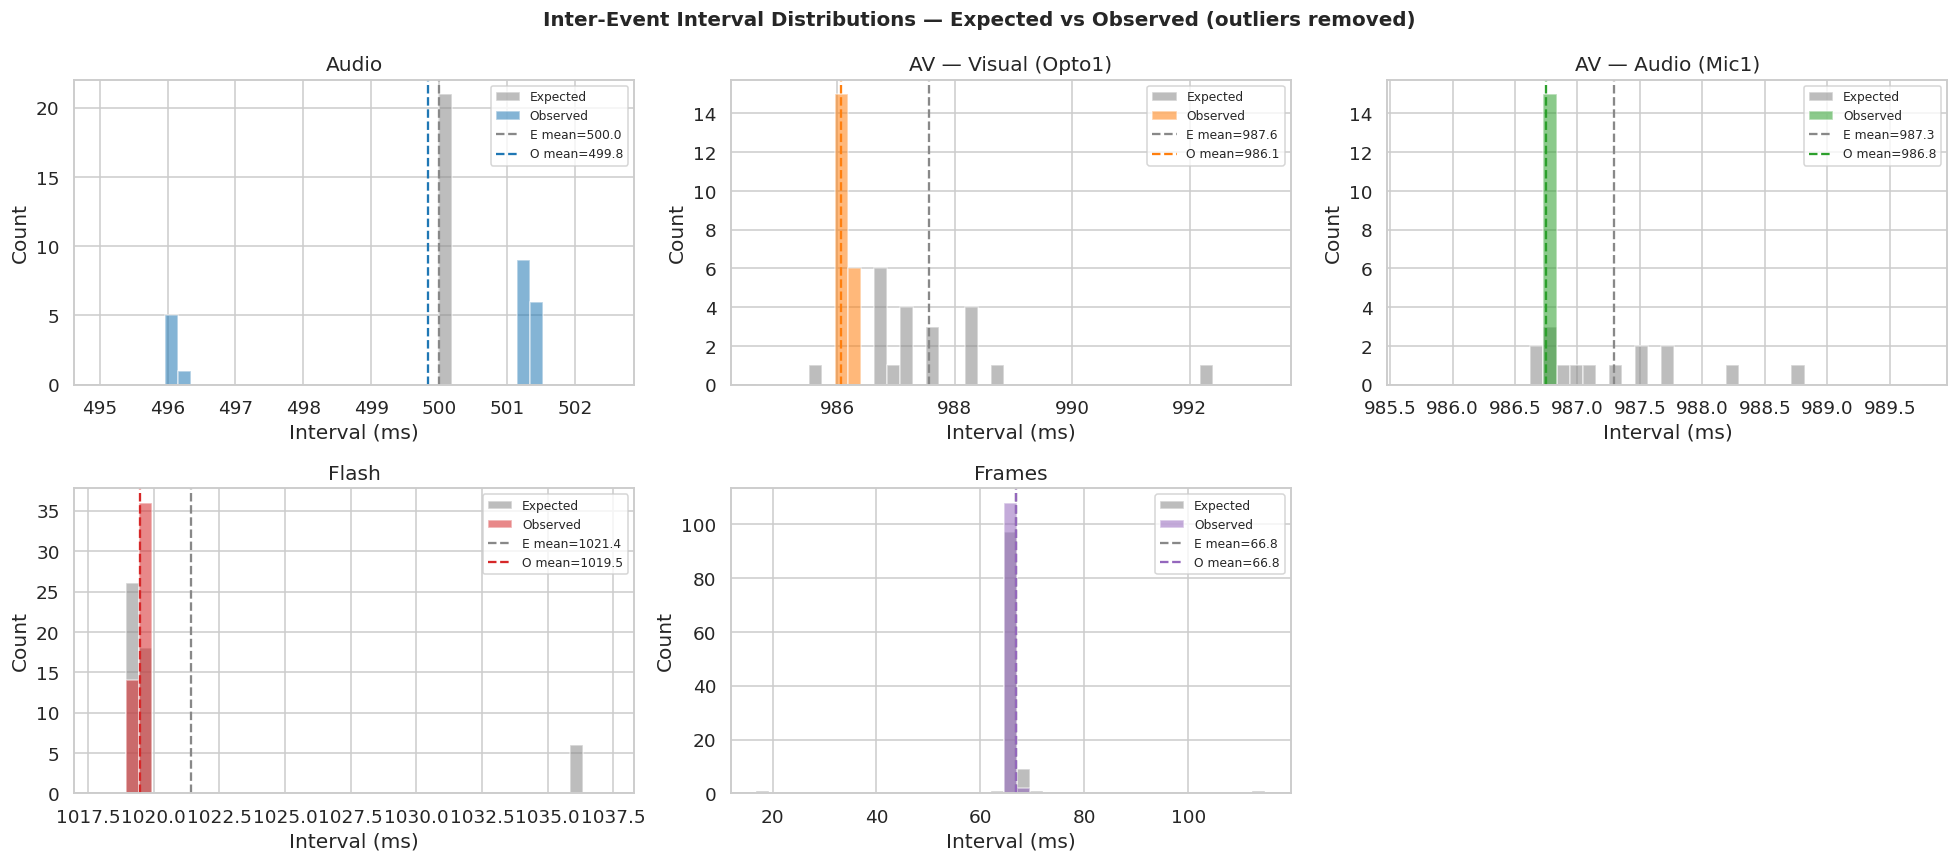

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle("Inter-Event Interval Distributions — Expected vs Observed (outliers removed)",
             fontsize=13, fontweight="bold")

for ax, cond, color in zip(axes.flat, CONDITIONS, COLORS):
    r = results[cond]
    plot_histogram_comparison(r["exp_clean"], r["obs_clean"], r["label"], ax, color)

axes.flat[-1].set_visible(False)   # hide the unused 6th panel

plt.tight_layout()
plt.savefig(ROOT / "histograms_expected_vs_observed.png", bbox_inches="tight")
plt.show()


## 10. Deviation Time-Series (Cleaned)

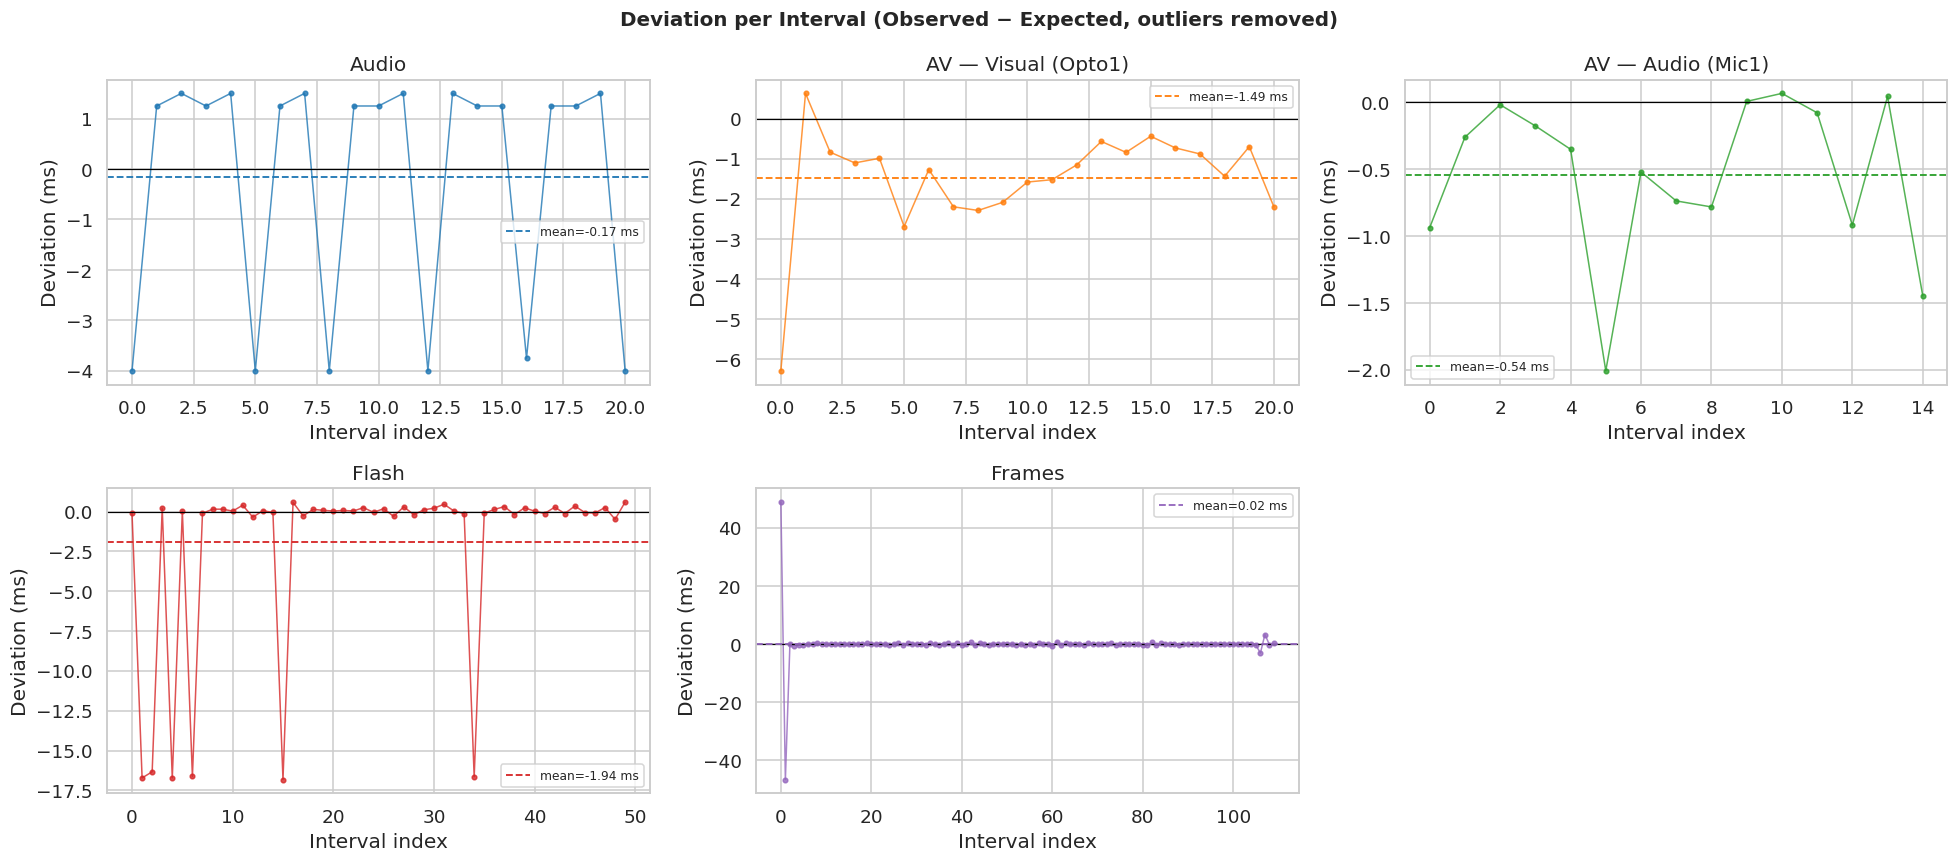

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle("Deviation per Interval (Observed − Expected, outliers removed)",
             fontsize=13, fontweight="bold")

for ax, cond, color in zip(axes.flat, CONDITIONS, COLORS):
    r = results[cond]
    diff_clean = r["obs_clean"] - r["exp_clean"]
    plot_deviation_timeseries(diff_clean, r["label"], ax, color)

axes.flat[-1].set_visible(False)   # hide the unused 6th panel

plt.tight_layout()
plt.savefig(ROOT / "deviation_timeseries.png", bbox_inches="tight")
plt.show()


## 11. Cross-Condition Summary

In [11]:
rows = []
for cond in CONDITIONS:
    r = results[cond]
    sc = r["stats_clean"]
    rows.append({
        "condition":       r["label"],
        "n_ref_events":    len(load_reference(cond)),
        "n_bbtk_events":   len(load_events(cond)),
        "n_intervals":     int(sc.loc["n", "value"]),
        "n_outliers":      int(r["outlier_mask"].sum()),
        "mean_diff_ms":    round(sc.loc["mean_diff", "value"], 3),
        "std_diff_ms":     round(sc.loc["std_diff", "value"], 3),
        "min_diff_ms":     round(sc.loc["min_diff", "value"], 3),
        "max_diff_ms":     round(sc.loc["max_diff", "value"], 3),
        "mean_abs_err_ms": round(sc.loc["mean_abs_err", "value"], 3),
    })

summary = pd.DataFrame(rows).set_index("condition")
print("Cross-condition timing reliability summary (after outlier removal)")
print("=" * 80)
print(summary.to_string())


Cross-condition timing reliability summary (after outlier removal)
                     n_ref_events  n_bbtk_events  n_intervals  n_outliers  mean_diff_ms  std_diff_ms  min_diff_ms  max_diff_ms  mean_abs_err_ms
condition                                                                                                                                      
Audio                          30             22           21           0        -0.167        2.460       -4.000        1.500            2.095
AV — Visual (Opto1)            30             26           21           4        -1.485        1.339       -6.286        0.628            1.545
AV — Audio (Mic1)              30             26           15          10        -0.541        0.604       -2.007        0.067            0.557
Flash                          60             57           50           6        -1.938        5.491      -16.821        0.596            2.166
Frames                        120            115          110        

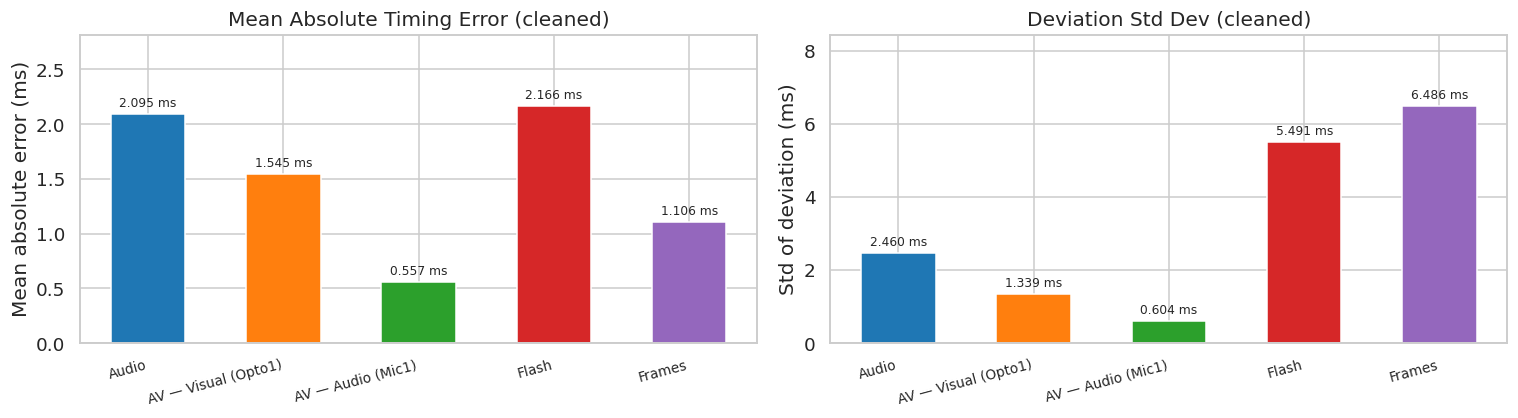

In [12]:
# Visual summary: mean absolute error & std dev per condition
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

labels = [r["label"] for r in results.values()]
x = np.arange(len(labels))

# --- Mean absolute error ---
ax = axes[0]
vals = summary["mean_abs_err_ms"].values
bars = ax.bar(x, vals, color=COLORS, edgecolor="white", width=0.55)
ax.bar_label(bars, fmt="%.3f ms", padding=3, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Mean absolute error (ms)")
ax.set_title("Mean Absolute Timing Error (cleaned)")
ax.set_ylim(0, max(vals) * 1.3)

# --- Std of deviation ---
ax = axes[1]
vals = summary["std_diff_ms"].values
bars = ax.bar(x, vals, color=COLORS, edgecolor="white", width=0.55)
ax.bar_label(bars, fmt="%.3f ms", padding=3, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Std of deviation (ms)")
ax.set_title("Deviation Std Dev (cleaned)")
ax.set_ylim(0, max(vals) * 1.3)

plt.tight_layout()
plt.savefig(ROOT / "summary_error_bars.png", bbox_inches="tight")
plt.show()


## 12. Per-Condition Detailed View

A compact 4-panel figure for each condition showing:
- Boxplot (raw)
- Histogram overlay (cleaned)
- Deviation time-series (cleaned)
- Descriptive stats table

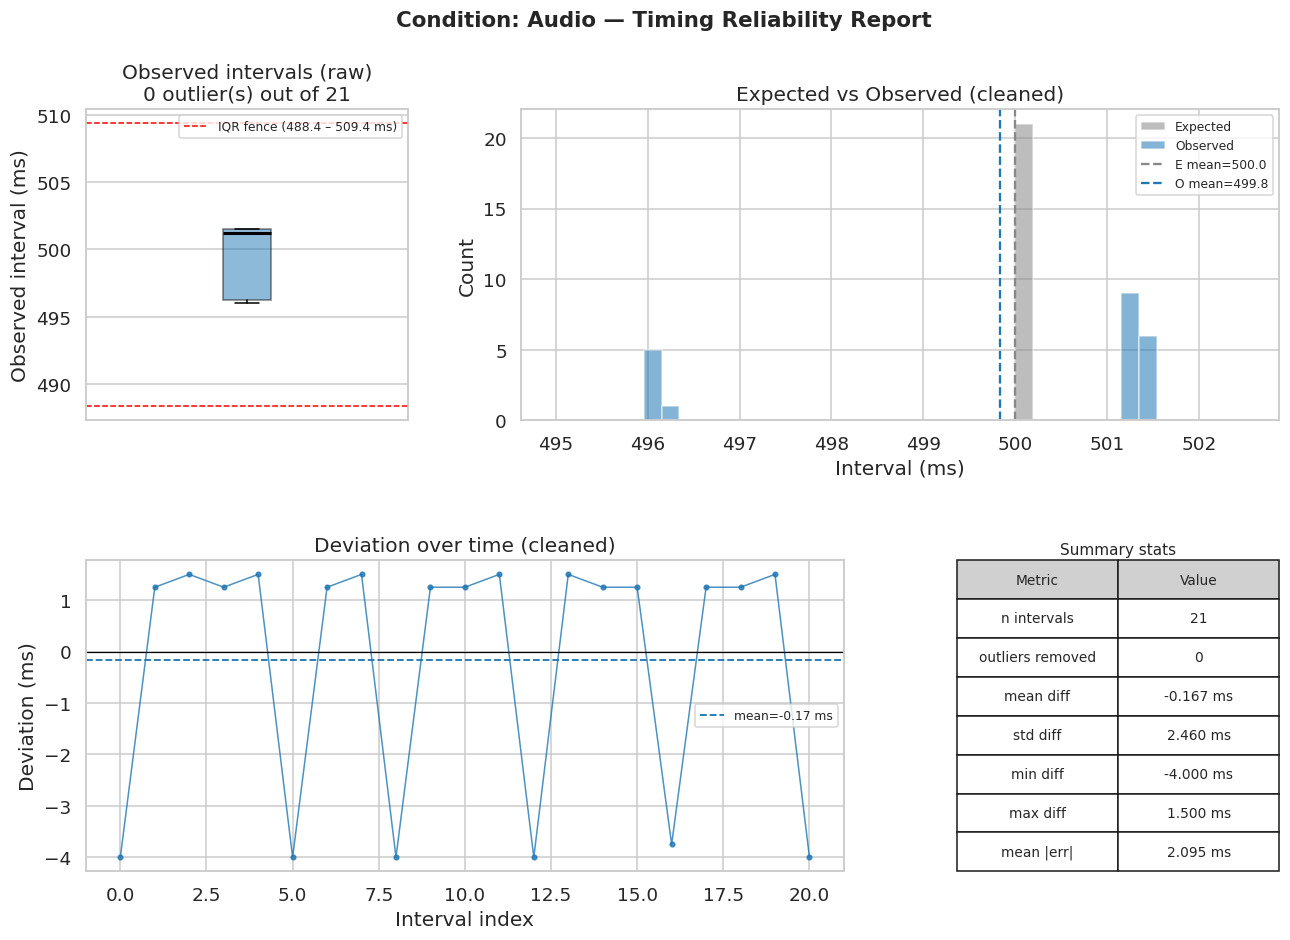

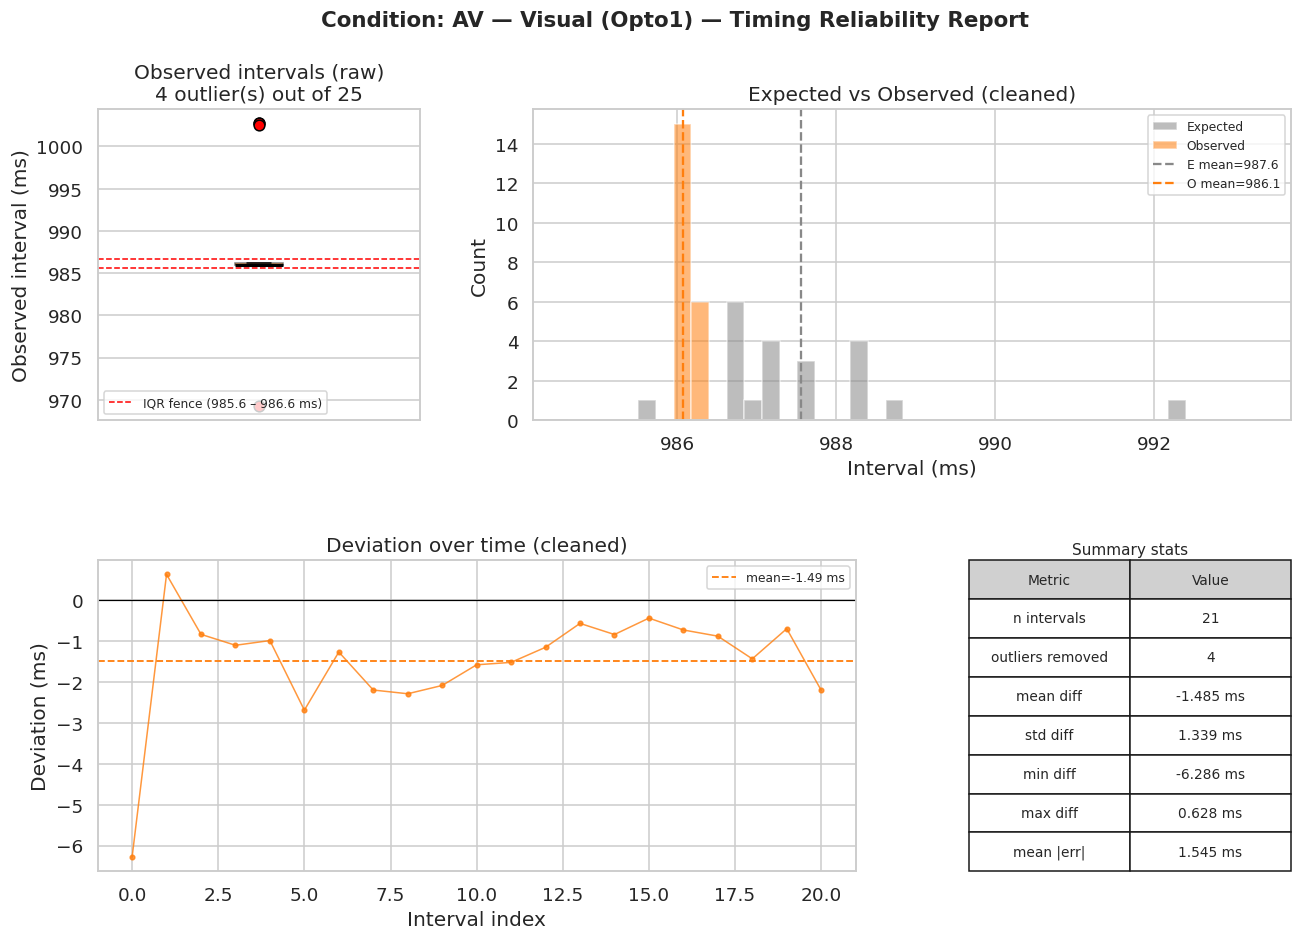

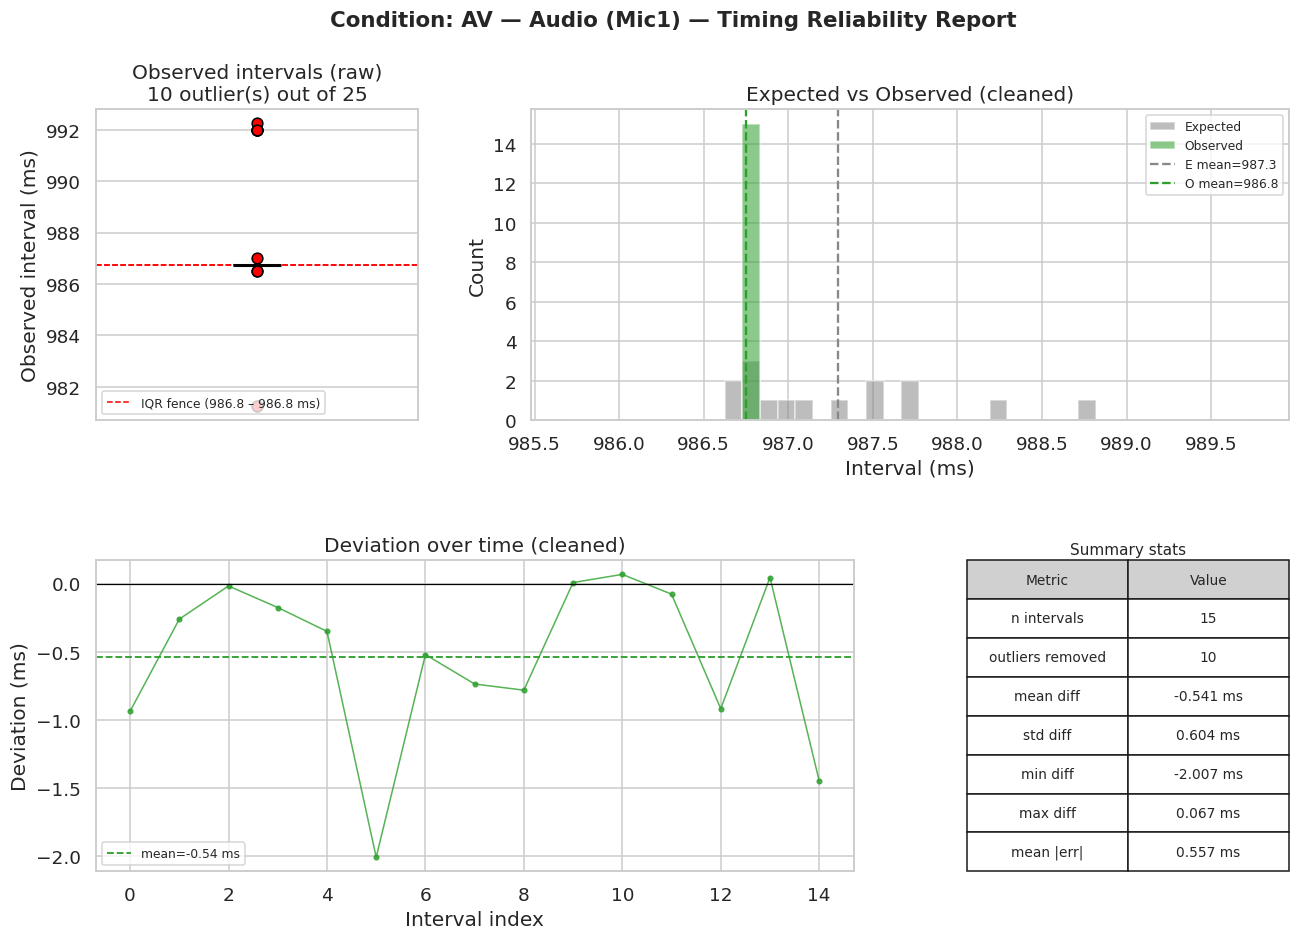

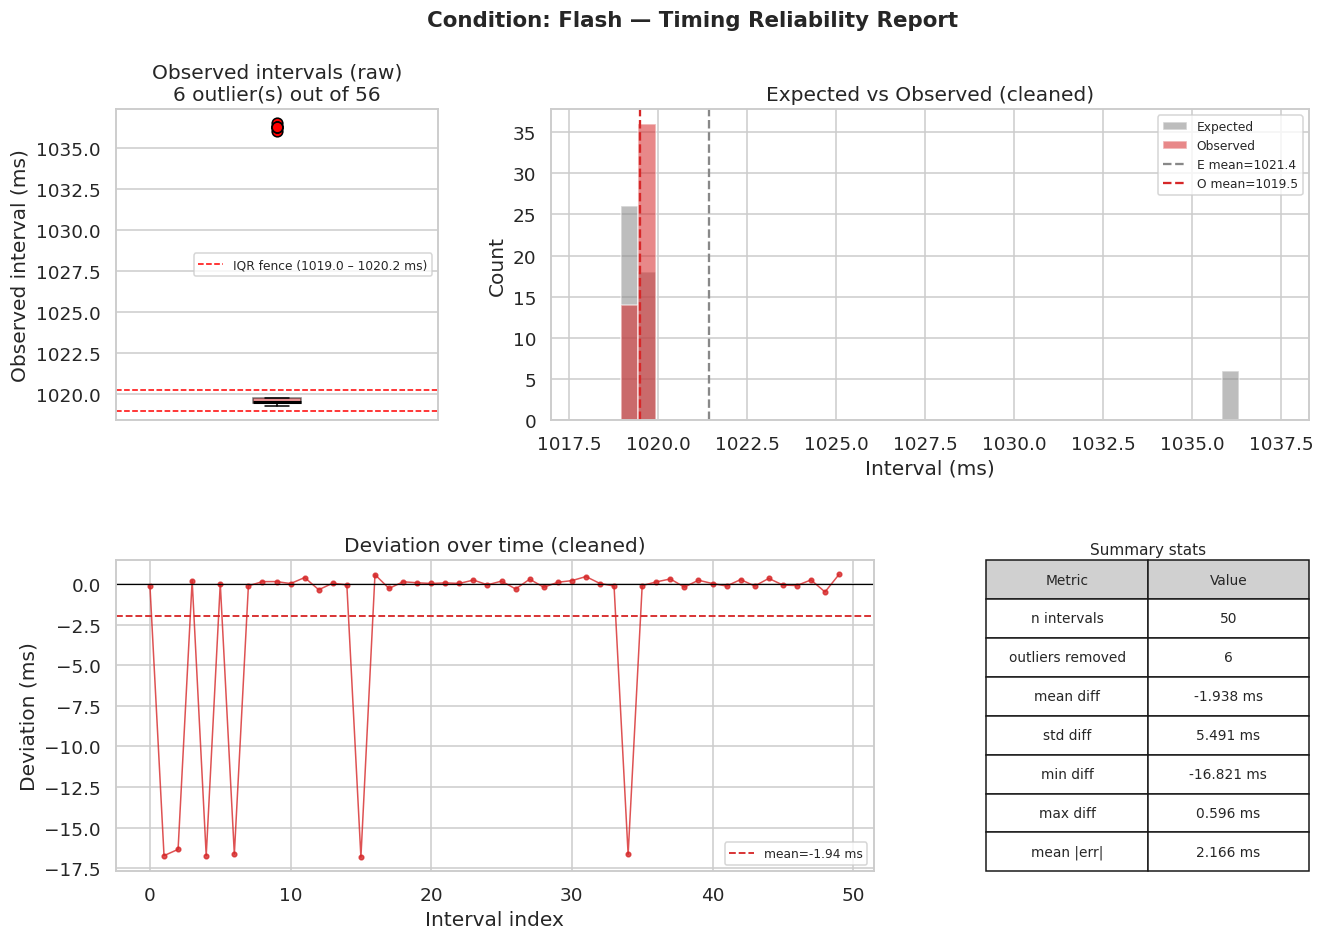

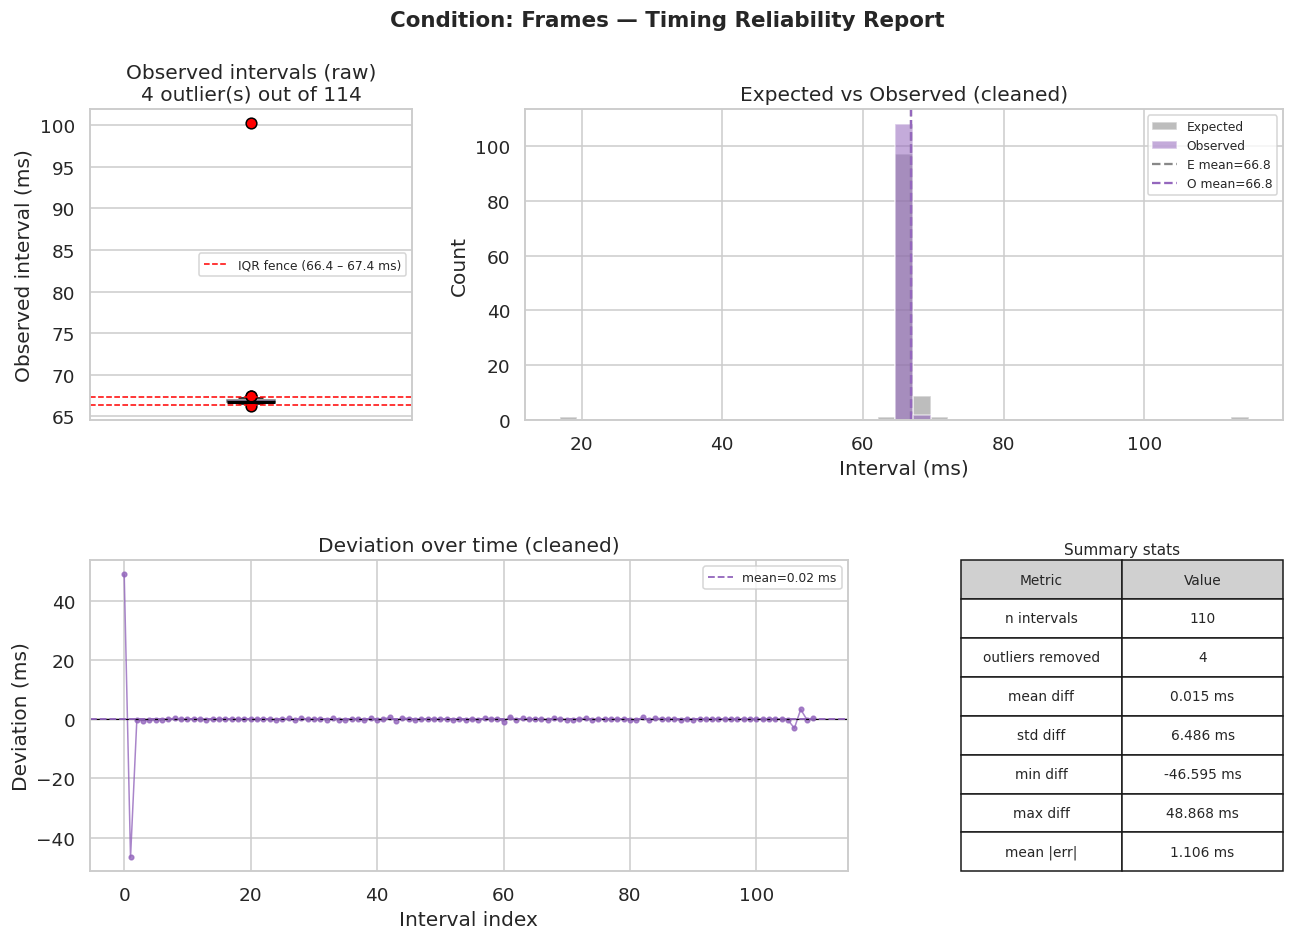

In [13]:
for cond, color in zip(CONDITIONS, COLORS):
    r = results[cond]
    diff_clean = r["obs_clean"] - r["exp_clean"]

    fig = plt.figure(figsize=(14, 9))
    fig.suptitle(f"Condition: {r['label']} — Timing Reliability Report",
                 fontsize=14, fontweight="bold")

    gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

    ax_box  = fig.add_subplot(gs[0, 0])
    ax_hist = fig.add_subplot(gs[0, 1:3])
    ax_ts   = fig.add_subplot(gs[1, 0:2])
    ax_tbl  = fig.add_subplot(gs[1, 2])

    plot_boxplot_with_outliers(
        r["obs_aln"], r["outlier_mask"],
        r["iqr_lo"], r["iqr_hi"],
        "Observed intervals (raw)", ax_box, color
    )
    plot_histogram_comparison(r["exp_clean"], r["obs_clean"],
                              "Expected vs Observed (cleaned)", ax_hist, color)
    plot_deviation_timeseries(diff_clean, "Deviation over time (cleaned)", ax_ts, color)

    ax_tbl.axis("off")
    sc = r["stats_clean"]
    tbl_data = [
        ["n intervals",      int(sc.loc["n",            "value"])],
        ["outliers removed",  int(r["outlier_mask"].sum())],
        ["mean diff",        f"{sc.loc['mean_diff',    'value']:.3f} ms"],
        ["std diff",         f"{sc.loc['std_diff',     'value']:.3f} ms"],
        ["min diff",         f"{sc.loc['min_diff',     'value']:.3f} ms"],
        ["max diff",         f"{sc.loc['max_diff',     'value']:.3f} ms"],
        ["mean |err|",       f"{sc.loc['mean_abs_err', 'value']:.3f} ms"],
    ]
    tbl = ax_tbl.table(
        cellText=tbl_data, colLabels=["Metric", "Value"],
        cellLoc="center", loc="center", bbox=[0, 0, 1, 1]
    )
    tbl.auto_set_font_size(False); tbl.set_fontsize(9)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor("#d0d0d0")
    ax_tbl.set_title("Summary stats", fontsize=10, pad=4)

    fname = cond.replace("_", "-")
    plt.savefig(ROOT / f"detail_{fname}.png", bbox_inches="tight")
    plt.show()
